In [1]:
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn  as sns
from mpl_toolkits.axes_grid1 import host_axes

In [2]:
df = pd.read_csv('ecommerce_sales_dataset.csv')

In [3]:
df

,order_id,order_date,customer_name,city,region,category,product,quantity,sales,profit,payment_method,customer_rating
0,ORD0001,22-02-2025,Melissa Williams,Lake Kimberlybury,North,Electronics,Laptop,5,1375.48,116.76,Net Banking,1
1,ORD0002,15-10-2025,Robert Molina,Williamschester,South,Electronics,Laptop,4,1316.77,264.02,Net Banking,2
2,ORD0003,05-08-2025,Frank Castillo,Cassandrashire,East,Groceries,Snacks,1,3842.28,345.48,Card,2
3,ORD0004,26-06-2025,Cassandra Walton,South Jeffreyview,East,Furniture,Sofa,2,645.18,47.86,UPI,4
4,ORD0005,13-11-2025,John Obrien,Justinton,East,Electronics,Tablet,2,2849.80,733.40,Cash,1
...,...,...,...,...,...,...,...,...,...,...,...,...
595,ORD0596,26-05-2025,Sean Nunez,Bellview,South,Electronics,Laptop,7,4969.93,448.95,Net Banking,5
596,ORD0597,14-07-2025,Crystal Castillo,Taylorside,North,Clothing,T-Shirt,2,3888.86,508.30,Net Banking,5
597,ORD0598,21-05-2025,Michelle Boyd,East Patricia,East,Electronics,Headphones,8,845.82,189.17,Net Banking,5
598,ORD0599,19-11-2025,Nicholas Evans,Robertbury,North,Furniture,Desk,10,479.29,92.43,Net Banking,5


In [4]:
df.head()

,order_id,order_date,customer_name,city,region,category,product,quantity,sales,profit,payment_method,customer_rating
0,ORD0001,22-02-2025,Melissa Williams,Lake Kimberlybury,North,Electronics,Laptop,5,1375.48,116.76,Net Banking,1
1,ORD0002,15-10-2025,Robert Molina,Williamschester,South,Electronics,Laptop,4,1316.77,264.02,Net Banking,2
2,ORD0003,05-08-2025,Frank Castillo,Cassandrashire,East,Groceries,Snacks,1,3842.28,345.48,Card,2
3,ORD0004,26-06-2025,Cassandra Walton,South Jeffreyview,East,Furniture,Sofa,2,645.18,47.86,UPI,4
4,ORD0005,13-11-2025,John Obrien,Justinton,East,Electronics,Tablet,2,2849.80,733.40,Cash,1


In [5]:
print(df.shape)

(600, 12)


In [6]:
df.columns

Index(['order_id', 'order_date', 'customer_name', 'city', 'region', 'category',
       'product', 'quantity', 'sales', 'profit', 'payment_method',
       'customer_rating'],
      dtype='object')

In [7]:
df.dtypes

order_id            object
order_date          object
customer_name       object
city                object
region              object
category            object
product             object
quantity             int64
sales              float64
profit             float64
payment_method      object
customer_rating      int64
dtype: object

In [8]:
df.isnull().sum()

order_id           0
order_date         0
customer_name      0
city               0
region             0
category           0
product            0
quantity           0
sales              0
profit             0
payment_method     0
customer_rating    0
dtype: int64

In [9]:
# Convert order_date to datetime.

df['order_date']=pd.to_datetime(df['order_date'])
print(df['order_date'])

0     2025-02-22
1     2025-10-15
2     2025-08-05
3     2025-06-26
4     2025-11-13
         ...    
595   2025-05-26
596   2025-07-14
597   2025-05-21
598   2025-11-19
599   2025-10-22
Name: order_date, Length: 600, dtype: datetime64[ns]


C:\Users\sweja\AppData\Local\Temp\ipykernel_28212\3399107212.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date']=pd.to_datetime(df['order_date'])


In [10]:
# Check duplicate rows.

df.duplicated().sum()

np.int64(0)

In [11]:
# Find total sales.

df['sales'].sum()

np.float64(1546940.1)

In [12]:
# Find average sales.
df['sales'].mean()

np.float64(2578.2335000000003)

In [13]:
# Find total profit.

df['profit'].sum()

np.float64(275178.54000000004)

In [14]:
# Find highest sales.

df['sales'].max()

np.float64(4987.16)

In [15]:
# Find lowest sales.

df['sales'].min()

np.float64(213.61)

In [16]:
# Total sales by category.

df.groupby('category')['sales'].sum()

category
Clothing       434548.69
Electronics    397555.00
Furniture      343716.51
Groceries      371119.90
Name: sales, dtype: float64

In [17]:
df['category'].unique()

array(['Electronics', 'Groceries', 'Furniture', 'Clothing'], dtype=object)

In [18]:
# Total profit by region.

df.groupby('region')['profit'].sum()

region
East     59988.83
North    69052.42
South    72213.71
West     73923.58
Name: profit, dtype: float64

In [19]:
# Average rating by product.

df.groupby('product')['customer_rating'].mean()

product
Chair         3.227273
Desk          3.243902
Headphones    3.162162
Jacket        2.931034
Jeans         3.306122
Juice         2.962963
Laptop        2.765957
Milk          2.718750
Mobile        3.060606
Rice          3.323529
Shoes         3.478261
Snacks        2.777778
Sofa          2.966667
T-Shirt       2.722222
Table         2.684211
Tablet        2.733333
Name: customer_rating, dtype: float64

In [20]:
# Top 5 cities with highest sales.

df.groupby('city')['sales'].sum().sort_values(ascending=False).head()

city
Baileymouth          8292.03
Lake David           8227.78
New Robert           6020.34
South Mauricestad    5077.25
North Lisa           4987.16
Name: sales, dtype: float64

In [21]:
# Show orders where sales > 3000.

df[df['sales']>3000]

,order_id,order_date,customer_name,city,region,category,product,quantity,sales,profit,payment_method,customer_rating
2,ORD0003,2025-08-05,Frank Castillo,Cassandrashire,East,Groceries,Snacks,1,3842.28,345.48,Card,2
5,ORD0006,2025-02-21,Darius Sullivan,Lake Christopher,West,Electronics,Mobile,5,4929.06,1300.43,Card,4
10,ORD0011,2025-09-10,Brett Gonzales,North Lisa,North,Groceries,Snacks,4,4987.16,421.83,UPI,1
11,ORD0012,2025-11-02,Teresa Gonzales,New Nathan,West,Furniture,Desk,7,3062.76,447.75,Card,5
12,ORD0013,2025-06-24,Edward Washington,North Keithfort,North,Electronics,Laptop,9,3804.21,921.19,Card,4
...,...,...,...,...,...,...,...,...,...,...,...,...
586,ORD0587,2025-03-11,Cameron Martin,Leahchester,West,Electronics,Mobile,10,4701.64,1053.30,Net Banking,3
591,ORD0592,2025-08-23,Stephanie Jenkins,West Jason,West,Furniture,Desk,1,3188.29,361.16,Net Banking,5
595,ORD0596,2025-05-26,Sean Nunez,Bellview,South,Electronics,Laptop,7,4969.93,448.95,Net Banking,5
596,ORD0597,2025-07-14,Crystal Castillo,Taylorside,North,Clothing,T-Shirt,2,3888.86,508.30,Net Banking,5


In [22]:
df[df['category']=='Electronics']

,order_id,order_date,customer_name,city,region,category,product,quantity,sales,profit,payment_method,customer_rating
0,ORD0001,2025-02-22,Melissa Williams,Lake Kimberlybury,North,Electronics,Laptop,5,1375.48,116.76,Net Banking,1
1,ORD0002,2025-10-15,Robert Molina,Williamschester,South,Electronics,Laptop,4,1316.77,264.02,Net Banking,2
4,ORD0005,2025-11-13,John Obrien,Justinton,East,Electronics,Tablet,2,2849.80,733.40,Cash,1
5,ORD0006,2025-02-21,Darius Sullivan,Lake Christopher,West,Electronics,Mobile,5,4929.06,1300.43,Card,4
12,ORD0013,2025-06-24,Edward Washington,North Keithfort,North,Electronics,Laptop,9,3804.21,921.19,Card,4
...,...,...,...,...,...,...,...,...,...,...,...,...
592,ORD0593,2025-08-21,Kim Brady,Velazquezchester,West,Electronics,Tablet,4,1240.99,266.65,Net Banking,1
593,ORD0594,2025-04-17,Julie Price,East Sarahmouth,North,Electronics,Mobile,9,1534.94,317.98,Cash,2
594,ORD0595,2025-10-23,Lauren Harrison,New Justin,East,Electronics,Headphones,1,897.80,52.17,Card,1
595,ORD0596,2025-05-26,Sean Nunez,Bellview,South,Electronics,Laptop,7,4969.93,448.95,Net Banking,5


In [23]:
# Sort by profit descending.

df.sort_values(by='profit', ascending=False)

,order_id,order_date,customer_name,city,region,category,product,quantity,sales,profit,payment_method,customer_rating
234,ORD0235,2025-02-05,Stephen Atkins,Josephville,West,Clothing,T-Shirt,9,4971.79,1410.23,UPI,3
5,ORD0006,2025-02-21,Darius Sullivan,Lake Christopher,West,Electronics,Mobile,5,4929.06,1300.43,Card,4
13,ORD0014,2025-05-15,Lynn Mcintyre,Port Ryan,South,Furniture,Table,1,4778.32,1285.19,UPI,3
242,ORD0243,2025-03-31,Rodney Gillespie,New Stephanieland,West,Clothing,T-Shirt,9,4752.90,1282.94,Net Banking,1
334,ORD0335,2025-09-24,Anthony Ortiz,Russoton,West,Clothing,T-Shirt,1,4622.12,1267.95,Card,4
...,...,...,...,...,...,...,...,...,...,...,...,...
78,ORD0079,2025-05-26,Andrea Martin,Loweryfurt,West,Clothing,Jeans,8,692.42,36.74,Net Banking,4
273,ORD0274,2025-11-14,Michael Lopez,Joneshaven,West,Electronics,Mobile,5,232.48,34.62,Card,4
295,ORD0296,2025-04-23,Daniel Sanchez,Adamberg,East,Groceries,Juice,3,596.82,34.45,UPI,3
386,ORD0387,2025-10-20,Thomas Clements,Manningburgh,South,Clothing,T-Shirt,5,331.76,20.71,Cash,2


In [24]:
# Create Profit Percentage column.

df['profit_percentage']= (df['profit']/df['sales'])*100

In [25]:
print(df['profit_percentage'])

0       8.488673
1      20.050578
2       8.991536
3       7.418085
4      25.735139
         ...    
595     9.033326
596    13.070669
597    22.365279
598    19.284775
599    11.491464
Name: profit_percentage, Length: 600, dtype: float64


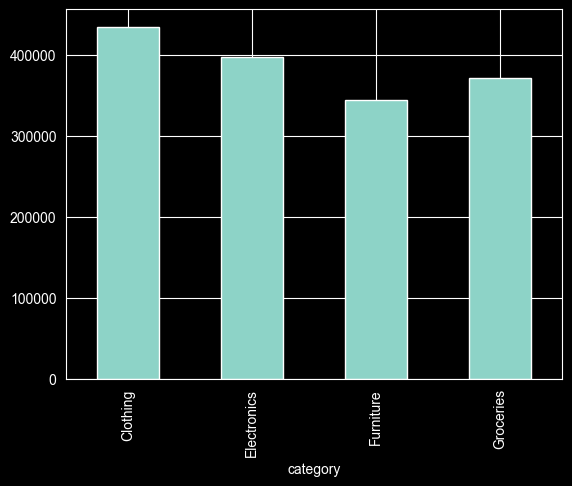

In [26]:
# visualization
# bar chart for a category sales
df.groupby('category')['sales'].sum().plot(kind='bar')
plt.show()

In [27]:
# line chart for monthly sales
monthly_sales.plot(kind='line')
plt.show()

NameError: name 'monthly_sales' is not defined

In [ ]:
# pie chart for payment method
df['payment_method'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.show()

In [ ]:
# boxplot for sales
sns.boxplot(x=df['sales'])
plt.show()

In [ ]:
# KPI
# total sales
# total profit
# total order
# avg orders value

total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].count()
avg_order_values = df['sales'].mean()


print('total_sales:',total_sales)
print('total_profit:',total_profit)
print('total_orders:',total_orders)
print('avg_order_values:',avg_order_values)

In [ ]:
# create a pivot table
pd.pivot_table (
    df,
    values='sales',
    index='region',
    columns='category',
    aggfunc='sum'
)

In [ ]:
# find correlation
df[['sales','profit','quantity']].corr()

In [ ]:
# create heatmap
sns.heatmap(df[['sales','profit','quantity']].corr(),annot=True)
plt.show()

In [ ]:
import mysql.connector
from sqlalchemy import create_engine

username = 'root'
password = 'Swejal_dahare'
host = 'Localhost'
database = 'project'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}/{database}'
)
print('connection to mysql successfully')

with engine.connect() as conn:
    print('connection to mysql successfully')


In [ ]:

table_name = 'sales_data'
df.to_sql(table_name,engine, if_exists='replace', index=False)
print('Data upload successfully')